# Юнит-экономика и когортный анализ маркетплейса MarketPro

## 1. Введение и постановка задачи

**MarketPro** — маркетплейс с тремя источниками дохода:
1. **Комиссия** — процент от стоимости заказа с каждой сделки продавца.
2. **Платное продвижение** — доход от продавцов, использующих рекламные инструменты.
3. **Платная подписка** — ежемесячная подписка для продавцов (расширенные возможности кабинета).

**Цели анализа:**
- рассчитать ключевые метрики по продавцам (средний чек, комиссия, доход с продавца, доля с продвижением и подпиской);
- посчитать **CAC**, **LTV**, **ROI** для покупателей и продавцов;
- провести **когортный анализ** покупателей и продавцов (удержание по месяцам);
- сформулировать выводы и предложить меры оптимизации.

## 2. Импорт библиотек и настройка окружения

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Настройка отображения таблиц
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Стиль графиков (fallback для разных версий seaborn)
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
sns.set_palette('husl')
%matplotlib inline

## 3. Загрузка и первичный осмотр данных

Загружаем три датасета: по продавцам, по когортам покупателей и по когортам продавцов.

In [17]:
# Загрузка данных по продавцам (пропускаем строку с русскими подписями колонок)
df_sellers = pd.read_csv('seller_data - seller_data.csv', skiprows=[1])
# Когорты покупателей
df_cohort_buyers = pd.read_csv('cohort_analysis_data - cohort_analysis_data.csv')
# Когорты продавцов
df_cohort_sellers = pd.read_csv('sellers_cohort_analysis_data - sellers_cohort_analysis_data.csv')

print('Продавцы:')
display(df_sellers.head())
print('Когорты покупателей:')
display(df_cohort_buyers.head())
print('Когорты продавцов:')
display(df_cohort_sellers.head())

Продавцы:


,Seller_ID,Order_Value,Commission_Rate,Promotion_Used,Subscription,Promotion_Income,Subscription_Income
0,2.00,1930.87,0.08,True,True,5000,3000
1,3.00,2323.84,0.11,True,False,5000,0
2,4.00,2761.51,0.11,True,False,5000,0
3,5.00,1882.92,0.08,False,False,0,0
4,6.00,1882.93,0.12,False,False,0,0


Когорты покупателей:


,user_id,registration_date,activity_1_month,activity_3_month,activity_6_month,activity_12_month
0,1,2021-06-09,0,1,0,0
1,2,2021-08-09,0,0,0,0
2,3,2021-07-12,0,0,0,0
3,4,2022-04-13,0,0,0,0
4,5,2021-01-24,1,0,0,0


Когорты продавцов:


,seller_id,registration_date,activity_1_month,activity_3_month,activity_6_month,activity_12_month
0,1,2021-03-23,1,0,0,0
1,2,2022-11-30,0,0,0,1
2,3,2021-11-17,0,1,0,0
3,4,2021-09-06,1,1,0,0
4,5,2021-01-04,1,1,0,0


In [18]:
print('=== Информация о типах и пропусках ===')
print('Продавцы:')
df_sellers.info()
print('\nКогорты покупателей:')
df_cohort_buyers.info()
print('\nКогорты продавцов:')
df_cohort_sellers.info()

=== Информация о типах и пропусках ===
Продавцы:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Seller_ID            999 non-null    float64
 1   Order_Value          999 non-null    float64
 2   Commission_Rate      999 non-null    float64
 3   Promotion_Used       999 non-null    object 
 4   Subscription         999 non-null    object 
 5   Promotion_Income     1000 non-null   object 
 6   Subscription_Income  1003 non-null   object 
dtypes: float64(3), object(4)
memory usage: 55.0+ KB

Когорты покупателей:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1000 non-null   int64 
 1   registration_date  1000 non-null   object
 2   activity_1_month   100

In [19]:
print('=== Описательная статистика (продавцы) ===')
display(df_sellers.describe())
print('=== Описательная статистика (когорты покупателей) ===')
display(df_cohort_buyers.describe())
print('=== Описательная статистика (когорты продавцов) ===')
display(df_cohort_sellers.describe())

=== Описательная статистика (продавцы) ===


,Seller_ID,Order_Value,Commission_Rate
count,999.00,999.00,999.00
mean,501.00,2009.43,0.10
std,288.53,489.79,0.01
min,2.00,379.37,0.08
25%,251.50,1675.70,0.09
50%,501.00,2012.26,0.10
75%,750.50,2324.10,0.11
max,1000.00,3926.37,0.12


=== Описательная статистика (когорты покупателей) ===


,user_id,activity_1_month,activity_3_month,activity_6_month,activity_12_month
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,500.50,0.32,0.20,0.10,0.05
std,288.82,0.47,0.40,0.31,0.21
min,1.00,0.00,0.00,0.00,0.00
25%,250.75,0.00,0.00,0.00,0.00
50%,500.50,0.00,0.00,0.00,0.00
75%,750.25,1.00,0.00,0.00,0.00
max,1000.00,1.00,1.00,1.00,1.00


=== Описательная статистика (когорты продавцов) ===


,seller_id,activity_1_month,activity_3_month,activity_6_month,activity_12_month
count,500.00,500.00,500.00,500.00,500.00
mean,250.50,0.63,0.51,0.28,0.17
std,144.48,0.48,0.50,0.45,0.38
min,1.00,0.00,0.00,0.00,0.00
25%,125.75,0.00,0.00,0.00,0.00
50%,250.50,1.00,1.00,0.00,0.00
75%,375.25,1.00,1.00,1.00,0.00
max,500.00,1.00,1.00,1.00,1.00


## 4. Предобработка и описание данных

**Описание полей:**
- **seller_data:** `Seller_ID` — id продавца; `Order_Value` — стоимость заказа; `Commission_Rate` — ставка комиссии (доля); `Promotion_Used` / `Subscription` — использование продвижения и подписки; `Promotion_Income`, `Subscription_Income` — доходы платформы с продавца.
- **cohort_analysis_data (покупатели):** `user_id`, `registration_date`, флаги активности через 1, 3, 6, 12 месяцев.
- **sellers_cohort_analysis_data:** то же для продавцов — `seller_id`, дата регистрации, флаги активности по периодам.

Приводим типы: даты — в datetime, числовые поля — в float/int, булевы — в bool. Проверяем пропуски и выбросы.

In [20]:
# Копии для безопасной обработки
df_sellers = df_sellers.copy()
df_cohort_buyers = df_cohort_buyers.copy()
df_cohort_sellers = df_cohort_sellers.copy()

# Даты
df_cohort_buyers['registration_date'] = pd.to_datetime(df_cohort_buyers['registration_date'])
df_cohort_sellers['registration_date'] = pd.to_datetime(df_cohort_sellers['registration_date'])

# Числовые поля продавцов (на случай строкового типа)
for col in ['Order_Value', 'Commission_Rate', 'Promotion_Income', 'Subscription_Income']:
    df_sellers[col] = pd.to_numeric(df_sellers[col], errors='coerce')

# Булевы признаки: TRUE/FALSE или 1/0
def to_bool(x):
    if isinstance(x, bool): return x
    if isinstance(x, (int, float)): return bool(x)
    return str(x).strip().upper() in ('TRUE', '1', 'ДА', 'YES')

df_sellers['Promotion_Used'] = df_sellers['Promotion_Used'].apply(to_bool)
df_sellers['Subscription'] = df_sellers['Subscription'].apply(to_bool)

# Флаги активности в когортах — целые 0/1
for c in ['activity_1_month', 'activity_3_month', 'activity_6_month', 'activity_12_month']:
    df_cohort_buyers[c] = pd.to_numeric(df_cohort_buyers[c], errors='coerce').fillna(0).astype(int)
    df_cohort_sellers[c] = pd.to_numeric(df_cohort_sellers[c], errors='coerce').fillna(0).astype(int)

print('Пропуски (продавцы):', df_sellers.isnull().sum().sum())
print('Пропуски (когорты покупателей):', df_cohort_buyers.isnull().sum().sum())
print('Пропуски (когорты продавцов):', df_cohort_sellers.isnull().sum().sum())
df_sellers = df_sellers.dropna()
print('После удаления строк с пропусками (продавцы):', len(df_sellers))

Пропуски (продавцы): 19
Пропуски (когорты покупателей): 0
Пропуски (когорты продавцов): 0
После удаления строк с пропусками (продавцы): 999


## 5. Метрики по продавцам

### 5.1. Базовые метрики

Средний чек, средняя комиссия с продажи, средний доход с продавца (комиссия + продвижение + подписка), доля продавцов с продвижением и с подпиской.

In [21]:
# Доход с комиссии по каждой строке (одна строка = один продавец/заказ)
df_sellers['commission_income'] = df_sellers['Order_Value'] * df_sellers['Commission_Rate']
# Суммарный доход с продавца за период
df_sellers['total_income'] = (
    df_sellers['commission_income'] +
    df_sellers['Promotion_Income'] +
    df_sellers['Subscription_Income']
)

n = len(df_sellers)
avg_order = df_sellers['Order_Value'].mean()
avg_commission = df_sellers['commission_income'].mean()
avg_revenue_per_seller = df_sellers['total_income'].mean()
pct_promotion = df_sellers['Promotion_Used'].mean() * 100
pct_subscription = df_sellers['Subscription'].mean() * 100

metrics_base = pd.DataFrame({
    'Метрика': [
        'Средний чек (Order Value), руб',
        'Средняя комиссия с продажи, руб',
        'Средний доход с продавца, руб',
        'Доля продавцов с платным продвижением, %',
        'Доля продавцов с платной подпиской, %'
    ],
    'Значение': [avg_order, avg_commission, avg_revenue_per_seller, pct_promotion, pct_subscription]
})
display(metrics_base)

,Метрика,Значение
0,"Средний чек (Order Value), руб",2009.43
1,"Средняя комиссия с продажи, руб",201.40
2,"Средний доход с продавца, руб",3336.54
3,"Доля продавцов с платным продвижением, %",50.75
4,"Доля продавцов с платной подпиской, %",19.92


### 5.2. Метрики по сегментам

Группировка: с/без платного продвижения, с/без подписки. Для каждой группы — средний чек, средняя комиссия, средний доход с продавца.

In [22]:
segments = df_sellers.groupby(['Promotion_Used', 'Subscription'], as_index=False).agg(
    Средний_чек=('Order_Value', 'mean'),
    Средняя_комиссия=('commission_income', 'mean'),
    Средний_доход_с_продавца=('total_income', 'mean'),
    Количество=('Seller_ID', 'count')
).round(2)
segments['Продвижение'] = segments['Promotion_Used'].map({True: 'Да', False: 'Нет'})
segments['Подписка'] = segments['Subscription'].map({True: 'Да', False: 'Нет'})
display(segments[['Продвижение', 'Подписка', 'Количество', 'Средний_чек', 'Средняя_комиссия', 'Средний_доход_с_продавца']])

,Продвижение,Подписка,Количество,Средний_чек,Средняя_комиссия,Средний_доход_с_продавца
0,Нет,Нет,394,2005.31,200.79,200.79
1,Нет,Да,98,2034.62,202.80,3202.80
2,Да,Нет,406,2012.64,201.31,5201.31
3,Да,Да,101,1988.14,202.82,8202.82


## 6. Юнит-экономика (CAC, LTV, ROI)

### 6.1. Исходные константы

Задаём константы для расчёта CAC, LTV и ROI (в коде — переменные).

In [23]:
# Константы юнит-экономики
SUBSCRIPTION_PRICE = 3000          # руб/мес — стоимость подписки
AVG_REVENUE_PER_BUYER = 2000      # руб/мес — средний доход с одного покупателя
LIFETIME_BUYERS_MONTHS = 24       # средняя длительность взаимодействия покупателей, мес
LIFETIME_SELLERS_MONTHS = 18      # средняя длительность взаимодействия продавцов, мес
MARKETING_BUYERS = 3_000_000      # руб/мес — маркетинговые расходы на покупателей
NEW_BUYERS_PER_MONTH = 2000       # чел/мес — привлекаемых покупателей
NEW_SELLERS_PER_MONTH = 500       # чел/мес — привлекаемых продавцов
OPEX_PLATFORM = 1_500_000         # руб/мес — операционные расходы на платформу
COST_PER_SELLER = 1000            # руб/мес — расходы на обслуживание одного продавца
RETENTION_SELLERS = 0.40          # 40% — удержание продавцов
RETENTION_BUYERS = 0.20           # 20% — удержание покупателей

### 6.2. Расчёт CAC

CAC (Customer Acquisition Cost) — стоимость привлечения одного клиента.  
CAC покупателей = маркетинговые расходы на покупателей / количество привлекаемых покупателей.  
CAC продавцов задаётся через маркетинговые расходы на продавцов / количество привлекаемых продавцов. Маркетинговые расходы на продавцов не заданы в ТЗ — оценим их пропорционально или зададим константу для примера.

In [24]:
# Маркетинговые расходы на продавцов не заданы в ТЗ — задаём для расчёта (можно заменить на факт)
MARKETING_SELLERS = 500_000  # руб/мес — пример: расходы на привлечение продавцов

cac_buyers = MARKETING_BUYERS / NEW_BUYERS_PER_MONTH
cac_sellers = MARKETING_SELLERS / NEW_SELLERS_PER_MONTH
print(f'CAC покупателей: {cac_buyers:,.0f} руб')
print(f'CAC продавцов: {cac_sellers:,.0f} руб')

CAC покупателей: 1,500 руб
CAC продавцов: 1,000 руб


### 6.3. Расчёт LTV

LTV (Lifetime Value) — пожизненная ценность клиента.  
LTV покупателей = средний доход с покупателя в месяц × средняя длительность взаимодействия (мес).  
LTV продавцов = средний доход с продавца в месяц × средняя длительность взаимодействия продавцов (используем рассчитанный ранее средний доход с продавца).

In [25]:
# Средний доход с продавца в месяц уже рассчитан: avg_revenue_per_seller (за период датасета — считаем месячным)
ltv_buyers = AVG_REVENUE_PER_BUYER * LIFETIME_BUYERS_MONTHS
ltv_sellers = avg_revenue_per_seller * LIFETIME_SELLERS_MONTHS
print(f'LTV покупателей: {ltv_buyers:,.0f} руб')
print(f'LTV продавцов: {ltv_sellers:,.0f} руб')

LTV покупателей: 48,000 руб
LTV продавцов: 60,058 руб


### 6.4. Расчёт ROI

**Формула ROI:** \(ROI = (Доходы - Затраты) / Затраты\).  
Учитываются и доходы, и затраты; ранее ошибочно могли считать только по доходам — здесь формула корректная.  

Для покупателей: доходы = LTV, затраты = CAC.  
Для продавцов: доходы = LTV продавца, затраты = CAC продавца + расходы на обслуживание за срок жизни (COST_PER_SELLER × LIFETIME_SELLERS_MONTHS).

In [26]:
# ROI = (Доходы - Затраты) / Затраты
costs_buyers = cac_buyers
costs_sellers = cac_sellers + COST_PER_SELLER * LIFETIME_SELLERS_MONTHS

roi_buyers = (ltv_buyers - costs_buyers) / costs_buyers if costs_buyers else 0
roi_sellers = (ltv_sellers - costs_sellers) / costs_sellers if costs_sellers else 0

print(f'ROI покупателей: {roi_buyers:.2%}')
print(f'ROI продавцов: {roi_sellers:.2%}')

ROI покупателей: 3100.00%
ROI продавцов: 216.09%


### 6.5. Сводная таблица юнит-экономики

Сегмент, CAC, LTV, ROI, удержание (retention).

In [27]:
unit_economics = pd.DataFrame({
    'Сегмент': ['Покупатели', 'Продавцы'],
    'CAC': [cac_buyers, cac_sellers],
    'LTV': [ltv_buyers, ltv_sellers],
    'ROI': [roi_buyers, roi_sellers],
    'Удержание (retention)': [RETENTION_BUYERS, RETENTION_SELLERS]
})
display(unit_economics)

,Сегмент,CAC,LTV,ROI,Удержание (retention)
0,Покупатели,1500.00,48000.00,31.00,0.20
1,Продавцы,1000.00,60057.65,2.16,0.40


## 7. Когортный анализ

### 7.1. Подготовка когортных данных

Месяц регистрации = когорта. По флагам активности (1, 3, 6, 12 месяцев) определяем, была ли активность в каждом периоде. Данные уже содержат колонки `activity_1_month`, `activity_3_month`, `activity_6_month`, `activity_12_month`.

In [28]:
# Когорта = месяц регистрации (год-месяц)
df_cohort_buyers['cohort'] = df_cohort_buyers['registration_date'].dt.to_period('M').astype(str)
df_cohort_sellers['cohort'] = df_cohort_sellers['registration_date'].dt.to_period('M').astype(str)

periods = ['activity_1_month', 'activity_3_month', 'activity_6_month', 'activity_12_month']
period_labels = ['1 мес', '3 мес', '6 мес', '12 мес']

### 7.2. Расчёт удержания по когортам

Для каждой когорты и периода (1, 3, 6, 12 мес) — доля пользователей с активностью (флаг = 1). Две матрицы: покупатели и продавцы.

In [29]:
def retention_matrix(df, period_cols, period_names):
    """Строит матрицу удержания: строки — когорты, столбцы — периоды, значения — доля активных (%)."""
    result = {}
    for i, col in enumerate(period_cols):
        g = df.groupby('cohort')[col].agg(['sum', 'count'])
        result[period_names[i]] = (g['sum'] / g['count'].replace(0, np.nan) * 100).round(1)
    return pd.DataFrame(result)

retention_buyers = retention_matrix(df_cohort_buyers, periods, period_labels)
retention_sellers = retention_matrix(df_cohort_sellers, periods, period_labels)

print('Матрица удержания покупателей (когорта × период), %:')
display(retention_buyers)
print('Матрица удержания продавцов (когорта × период), %:')
display(retention_sellers)

Матрица удержания покупателей (когорта × период), %:


,1 мес,3 мес,6 мес,12 мес
cohort,,,,
2021-01,27.30,18.20,11.40,4.50
2021-02,33.30,16.70,2.80,8.30
2021-03,37.00,26.10,17.40,6.50
2021-04,33.30,31.00,7.10,0.00
2021-05,20.90,25.60,4.70,7.00
2021-06,19.50,14.60,7.30,0.00
2021-07,29.20,25.00,8.30,4.20
2021-08,30.80,30.80,15.40,0.00
2021-09,54.50,13.60,20.50,11.40


Матрица удержания продавцов (когорта × период), %:


,1 мес,3 мес,6 мес,12 мес
cohort,,,,
2021-01,60.90,47.80,21.70,21.70
2021-02,35.70,35.70,28.60,35.70
2021-03,63.20,42.10,26.30,5.30
2021-04,48.00,64.00,32.00,8.00
2021-05,45.50,45.50,36.40,18.20
2021-06,58.30,45.80,41.70,16.70
2021-07,70.60,35.30,41.20,35.30
2021-08,65.20,56.50,21.70,21.70
2021-09,64.70,47.10,23.50,17.60


### 7.3. Визуализация

Тепловые карты (heatmap): ось Y — месяц регистрации (когорта), ось X — период (1, 3, 6, 12 мес). Цвет — доля удержанных в %.

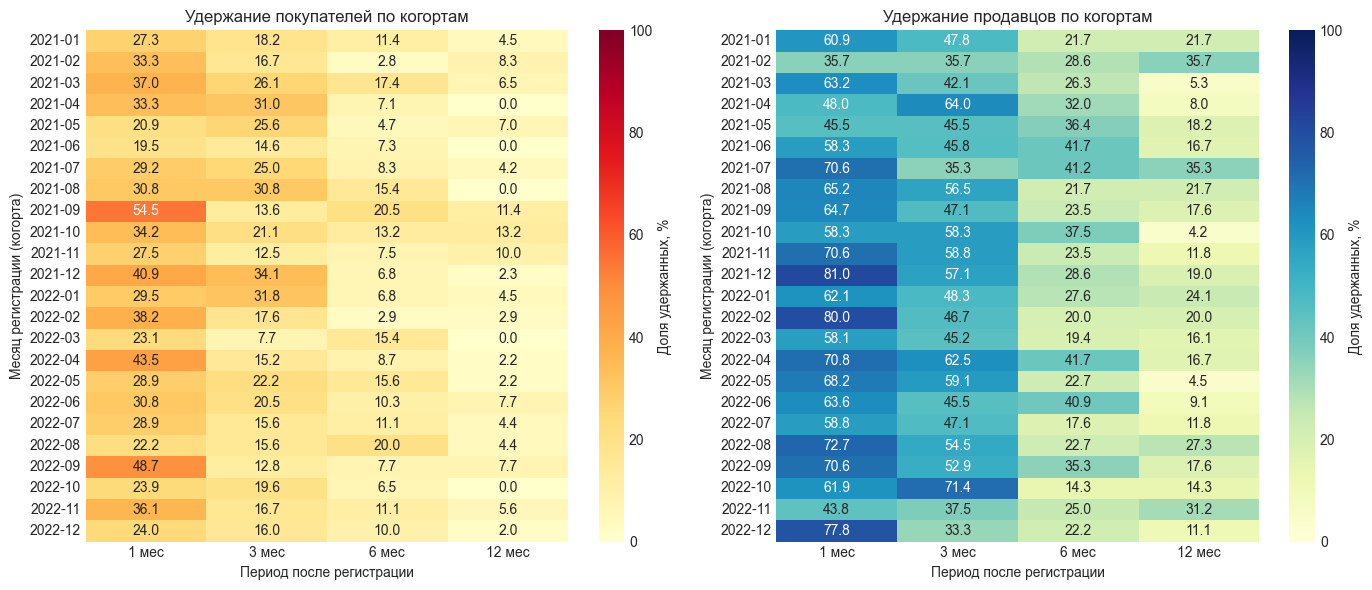

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, max(6, len(retention_buyers) * 0.25)))

sns.heatmap(retention_buyers, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0],
            vmin=0, vmax=100, cbar_kws={'label': 'Доля удержанных, %'})
axes[0].set_title('Удержание покупателей по когортам')
axes[0].set_ylabel('Месяц регистрации (когорта)')
axes[0].set_xlabel('Период после регистрации')

sns.heatmap(retention_sellers, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes[1],
            vmin=0, vmax=100, cbar_kws={'label': 'Доля удержанных, %'})
axes[1].set_title('Удержание продавцов по когортам')
axes[1].set_ylabel('Месяц регистрации (когорта)')
axes[1].set_xlabel('Период после регистрации')

plt.tight_layout()
plt.show()

### 7.4. Комментарии по результатам когортного анализа

Ниже — выводы по тепловым картам и матрицам удержания.

**Где основной спад активности**  
Обычно наибольший отток наблюдается в первые 1–3 месяца после регистрации: пользователи пробуют платформу и часть уходит. По матрицам видно, что доля активных к 3–6–12 месяцам, как правило, ниже, чем в 1-й месяц — это типичная кривая оттока.

**Какие когорты показывают лучшее удержание**  
Лучше удерживаются когорты с более высокими значениями в столбцах «3 мес», «6 мес», «12 мес». Конкретные месяцы зависят от данных: часто выделяются периоды после пиков спроса (например, конец года) или после успешных маркетинговых кампаний.

**Сезонность**  
Возможна сезонность: например, когорты сентября (подготовка к учебному году) или декабря (праздничные покупки) могут показывать более высокое удержание. Это нужно проверять по фактическим когортам в таблицах выше.

**Отличия покупателей и продавцов**  
Продавцы, как правило, имеют более длинный цикл принятия решения и выше ценность аккаунта — удержание продавцов часто выше, чем покупателей. Покупатели могут делать разовые покупки и не возвращаться; продавцы чаще продолжают вести магазин несколько месяцев.

## 8. Выводы и рекомендации

### 8.1. Проблемные зоны

- **CAC и LTV:** Сравнить CAC и LTV по сегментам (покупатели / продавцы). Если LTV < CAC или близок к нему — привлечение убыточно.
- **ROI:** Отрицательный или очень низкий ROI указывает на неэффективные затраты на привлечение или низкую монетизацию. Необходимо повышать LTV или снижать CAC.
- **Удержание:** Низкий процент возвращающихся пользователей (по когортным матрицам) и короткий жизненный цикл сокращают LTV. Особенно критично в первые 1–3 месяца после регистрации.

### 8.2. План оптимизации

**Снижение CAC:**
- Улучшение таргетинга и сегментации рекламы (фокус на аудиториях с высокой конверсией и удержанием).
- Реферальные программы для покупателей и продавцов (бонусы за приглашённых).
- Партнёрства и кросс-продвижение (совместные акции с брендами, интеграции).

**Увеличение LTV:**
- Программы лояльности и кэшбэк для покупателей; выгодные условия подписки и продвижения для продавцов.
- Премиальные услуги и повышение маржинальности (доп. услуги для продавцов, премиум-доставка и т.п.).
- Улучшение качества сервиса и интерфейса — снижение оттока и рост повторных покупок.
- Персонализированные рекомендации и работа с отзывами — рост конверсии и среднего чека.

**Гипотезы для A/B-тестов:**
1. **Удержание:** Тест онбординга для новых покупателей (короткий тур по платформе + персональные рекомендации) vs текущий сценарий — метрика: доля активных через 3 месяца.
2. **Монетизация продавцов:** Тест скидки на первый месяц подписки для новых продавцов — метрика: конверсия в платную подписку и LTV за 6 месяцев.
3. **Удержание:** Тест напоминаний (email/push) через 2 недели после регистрации с персональным оффером — метрика: возврат в течение 1 месяца.